## Simplification des canaux

Dans ce notebook, les canaux ne sont pas modélisés physiquement.

👉 On utilise des valeurs constantes simples pour :

- faciliter la compréhension
- visualiser le rôle des variables
- se concentrer sur l'algorithme d'optimisation

Les canaux seront remplacés par un modèle réaliste ultérieurement.

## Paramètres du système

- M : nombre d'antennes AP
- N : nombre d'éléments RIS
- K : nombre d'utilisateurs

In [314]:
import numpy as np

M = 10
N = 10
K = 2

sigma2 = 1e-3

omega = np.ones(K)

W = (np.random.randn(M, K) + 1j*np.random.randn(M, K)) / np.sqrt(2)
W = W / np.linalg.norm(W)


## Modélisation des canaux

On modélise les canaux comme des variables gaussiennes complexes (Rayleigh fading) pondérées par un path-loss dépendant de la distance.

Pour chaque lien :

$$
h \sim \mathcal{CN}(0, \beta(d))
\quad \Longleftrightarrow \quad
h = \sqrt{\beta(d)} \cdot g,\; g \sim \mathcal{CN}(0,1)
$$

où :

- $\beta(d) = d^{-\alpha}$ est l'atténuation (path-loss)
- $\alpha$ est l'exposant de propagation

On construit ensuite :

- $h_{d,k}$ : canal direct AP → utilisateur k
- $h_{r,k}$ : canal RIS → utilisateur k
- $G$ : canal AP → RIS
- $H_{r,k} = \mathrm{diag}(h_{r,k}^*)\, G$

In [315]:
alpha = 2.2

def path_loss(d):
    return d**(-alpha)

def rayleigh(shape):
    return (np.random.randn(*shape) + 1j*np.random.randn(*shape)) / np.sqrt(2)

def channel(shape, d):
    return np.sqrt(path_loss(d)) * rayleigh(shape)

# distances identiques
d_ap_user = 20
d_ris_user = 20
d_ap_ris = 60

hd = []
Hr = []

# canal AP -> RIS (commun)
G = channel((N, M), d_ap_ris)

# matrice de phase RIS
phi = 2 * np.pi * np.random.rand(N)
Theta = np.diag(np.exp(1j * phi))

for k in range(K):
    hd_k = channel((M,), d_ap_user)
    hr_k = channel((N,), d_ris_user)

    # canal RIS corrigé
    Hr_k = np.diag(np.conj(hr_k)) @ Theta @ G

    hd.append(hd_k)
    Hr.append(Hr_k)

## Vecteur de phase du RIS

Chaque élément du RIS modifie la phase du signal :

$$
\theta_n = e^{j\phi_n}, \quad |\theta_n| = 1
$$

In [316]:
theta = np.exp(1j * 2*np.pi*np.random.rand(N))

# Calcul du canal global

In [317]:
def compute_hk(hd, Hr, theta):
    hk = []
    for k in range(K):
        h = hd[k] + Hr[k].conj().T @ theta
        hk.append(h)
    return hk

## Mise à jour de $w_k$ (WMMSE)

On utilise les équations complètes du papier :

- $\chi_k$
- $\kappa_k$
- mise à jour de $w_k$

In [318]:
import numpy as np

# =========================
# PARAMÈTRES
# =========================
PT = 1.0  # puissance totale max

# =========================
# UPDATE W
# =========================
def update_W(hk, W):
    chi = np.zeros(K, dtype=complex)
    kappa = np.zeros(K, dtype=complex)
    
    # =========================
    # calcul chi
    # =========================
    for k in range(K):
        num = hk[k].conj() @ W[:, k]
        
        denom = 0
        for i in range(K):
            denom += np.abs(hk[k].conj() @ W[:, i])**2
        
        denom += sigma2
        
        chi[k] = num / denom
    
    # =========================
    # calcul kappa
    # =========================
    for k in range(K):
        val = hk[k].conj() @ W[:, k]
        kappa[k] = 1 / (1 - np.conj(chi[k]) * val)
    
    # =========================
    # matrice A0 (sans lambda)
    # =========================
    A0 = np.zeros((M, M), dtype=complex)
    
    for i in range(K):
        hi = hk[i].reshape(-1,1)
        A0 += omega[i] * np.abs(chi[i])**2 * kappa[i] * (hi @ hi.conj().T)
    
    # =========================
    # fonction puissance
    # =========================
    def compute_power(lambda_):
        A = A0 + lambda_ * np.eye(M)
        A_inv = np.linalg.inv(A)
        
        W_tmp = np.zeros((M, K), dtype=complex)
        
        for k in range(K):
            W_tmp[:, k] = omega[k] * chi[k] * kappa[k] * (A_inv @ hk[k])
        
        return np.sum(np.linalg.norm(W_tmp, axis=0)**2)
    
    # =========================
    # recherche de lambda
    # =========================
    if compute_power(0) <= PT:
        lambda_ = 0
    else:
        lambda_min = 0
        lambda_max = 1
        
        while compute_power(lambda_max) > PT:
            lambda_max *= 2
        
        for _ in range(30):
            lambda_ = (lambda_min + lambda_max) / 2
            power = compute_power(lambda_)
            
            if power > PT:
                lambda_min = lambda_
            else:
                lambda_max = lambda_
    
    # =========================
    # update W final
    # =========================
    A = A0 + lambda_ * np.eye(M)
    A_inv = np.linalg.inv(A)
    
    W_new = np.zeros((M, K), dtype=complex)
    
    for k in range(K):
        W_new[:, k] = omega[k] * chi[k] * kappa[k] * (A_inv @ hk[k])
    
    return W_new

## Décomposition du signal

On définit :

$$
a_{i,k} = H_{r,k} w_i
$$

$$
b_{i,k} = h_{d,k}^H w_i
$$

Cela permet de séparer :
- la contribution du RIS
- la contribution directe

In [319]:
def compute_a_b(Hr, hd, W):
    a = {}
    b = {}
    
    for i in range(K):
        for k in range(K):
            a[(i,k)] = Hr[k] @ W[:, i]
            b[(i,k)] = hd[k].conj() @ W[:, i]
    
    return a, b

## Définition de $A_k$

$$
A_k =
\frac{\sum_{i=1}^K a_{i,k} a_{i,k}^H \theta + \sum_{i=1}^K a_{i,k} b_{i,k}^*}
{\sum_{i=1}^K \left| \theta^H a_{i,k} + b_{i,k} \right|^2 + \sigma_0^2}
-
\frac{\sum_{i \ne k} a_{i,k} a_{i,k}^H \theta + \sum_{i \ne k} a_{i,k} b_{i,k}^*}
{\sum_{i \ne k} \left| \theta^H a_{i,k} + b_{i,k} \right|^2 + \sigma_0^2}
$$

In [320]:
def compute_Ak(theta, a, b):
    A_list = []

    for k in range(K):

        num1 = 0
        for i in range(K):
            ai = a[(i,k)]
            bi = b[(i,k)]
            num1 += ai * (ai.conj().T @ theta) + ai * np.conj(bi)

        den1 = 0
        for i in range(K):
            val = theta.conj().T @ a[(i,k)] + b[(i,k)]
            den1 += np.abs(val)**2
        den1 += sigma2

        num2 = 0
        for i in range(K):
            if i != k:
                ai = a[(i,k)]
                bi = b[(i,k)]
                num2 += ai * (ai.conj().T @ theta) + ai * np.conj(bi)

        den2 = 0
        for i in range(K):
            if i != k:
                val = theta.conj().T @ a[(i,k)] + b[(i,k)]
                den2 += np.abs(val)**2
        den2 += sigma2

        Ak = num1/den1 - num2/den2
        A_list.append(Ak)

    return A_list

## Gradient euclidien

$$
\nabla f_C = \sum_k 2 \omega_k A_k
$$

In [321]:
def compute_gradient(theta, a, b):
    A_list = compute_Ak(theta, a, b)
    
    grad = np.zeros_like(theta, dtype=complex)
    for k in range(K):
        grad += 2 * omega[k] * A_list[k]
    
    return grad

## Riemannian Conjugate Gradient (formules exactes)

1) Gradient riemannien :

$$
\mathrm{grad}\, f_C = \nabla f_C - \mathrm{Re}\{\nabla f_C \circ \theta^*\} \circ \theta
$$

---

2) Direction de recherche :

$$
\mathbf{d} = -\mathrm{grad}\, f_C + \tau_1 \mathcal{T}(\bar{\mathbf{d}})
$$

avec :

$$
\mathcal{T}(\mathbf{d}) = \bar{\mathbf{d}} - \mathrm{Re}\{\mathbf{d} \circ \theta^*\} \circ \theta
$$

---

3) Retraction :

$$
\theta_n \leftarrow \frac{(\theta + \tau_2 \mathbf{d})_n}{\left|(\theta + \tau_2 \mathbf{d})_n\right|}
$$

In [322]:
# 1. Gradient riemannien
def grad_fC(theta, grad_euclid):
    return grad_euclid - np.real(grad_euclid * np.conj(theta)) * theta


# 2. Transport
def T(d_bar, theta):
    return d_bar - np.real(d_bar * np.conj(theta)) * theta


# 3. Direction
def compute_d(grad_fC_val, d_bar, tau1, theta):
    if d_bar is None:
        return -grad_fC_val
    else:
        return -grad_fC_val + tau1 * T(d_bar, theta)


# 4. Retractation
def update_theta(theta, d, tau2):
    theta_new = theta + tau2 * d
    return theta_new / np.abs(theta_new)


In [323]:
def compute_wsr(hk, W):
    wsr = 0

    for k in range(K):
        hk_H = hk[k].conj()

        signal = np.abs(hk_H @ W[:, k])**2

        interference = 0
        for i in range(K):
            if i != k:
                interference += np.abs(hk_H @ W[:, i])**2

        sinr = signal / (interference + sigma2)

        wsr += omega[k] * np.log(1 + sinr)

    return np.real(wsr)

In [324]:
def rcg_iteration(theta, a, b, d_bar, tau1=0.5, tau2=1e-3):

    # gradient euclidien
    grad_euclid = compute_gradient(theta, a, b)

    # gradient riemannien
    grad_riem = grad_fC(theta, grad_euclid)

    # direction
    if d_bar is None:
        d = -grad_riem
    else:
        d = -grad_riem + tau1 * T(d_bar, theta)

    theta_new = update_theta(theta, d, tau2)

    return theta_new, d

In [325]:
n_iter = 30
wsr_values = []
d_bar = None

for it in range(n_iter):

    # === canal équivalent
    hk = compute_hk(hd, Hr, theta)

    # === update W (WMMSE)
    W = update_W(hk, W)
    W = W / (np.linalg.norm(W) + 1e-9)

    # === calcul a, b
    a, b = compute_a_b(Hr, hd, W)

    # === update theta (RCG)
    theta, d_bar = rcg_iteration(theta, a, b, d_bar)

    # === nouveau canal
    hk = compute_hk(hd, Hr, theta)

    # === WSR
    wsr = compute_wsr(hk, W)
    wsr_values.append(wsr)

    print(f"Iter {it:02d} | WSR = {wsr:.4f}")

Iter 00 | WSR = 3.9578
Iter 01 | WSR = 4.0090
Iter 02 | WSR = 4.0214
Iter 03 | WSR = 4.0286
Iter 04 | WSR = 4.0330
Iter 05 | WSR = 4.0355
Iter 06 | WSR = 4.0371
Iter 07 | WSR = 4.0380
Iter 08 | WSR = 4.0385
Iter 09 | WSR = 4.0388
Iter 10 | WSR = 4.0390
Iter 11 | WSR = 4.0391
Iter 12 | WSR = 4.0392
Iter 13 | WSR = 4.0392
Iter 14 | WSR = 4.0393
Iter 15 | WSR = 4.0393
Iter 16 | WSR = 4.0393
Iter 17 | WSR = 4.0393
Iter 18 | WSR = 4.0393
Iter 19 | WSR = 4.0393
Iter 20 | WSR = 4.0393
Iter 21 | WSR = 4.0393
Iter 22 | WSR = 4.0393
Iter 23 | WSR = 4.0393
Iter 24 | WSR = 4.0393
Iter 25 | WSR = 4.0393
Iter 26 | WSR = 4.0393
Iter 27 | WSR = 4.0393
Iter 28 | WSR = 4.0393
Iter 29 | WSR = 4.0393


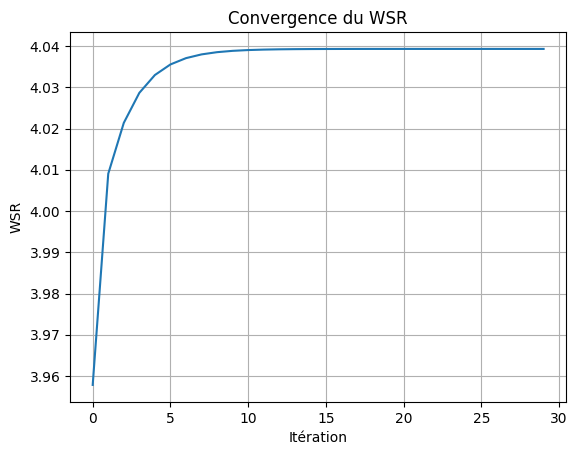

In [326]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(wsr_values)
plt.xlabel("Itération")
plt.ylabel("WSR")
plt.title("Convergence du WSR")
plt.grid()
plt.show()

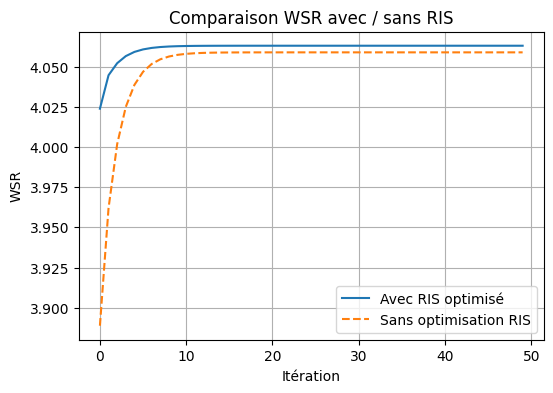

In [327]:
def run_simulation(optimize_theta=True):

    theta = np.exp(1j * 2*np.pi*np.random.rand(N))
    W = (np.random.randn(M, K) + 1j*np.random.randn(M, K)) / np.sqrt(2)
    W = W / np.linalg.norm(W)

    wsr_values = []
    d_bar = None

    for it in range(n_iter):

        hk = compute_hk(hd, Hr, theta)

        # update W
        W = update_W(hk, W)
        W = W / (np.linalg.norm(W) + 1e-9)

        # a, b
        a, b = compute_a_b(Hr, hd, W)

        # avec ou sans optimisation RIS
        if optimize_theta:
            theta, d_bar = rcg_iteration(theta, a, b, d_bar)

        # nouveau canal
        hk = compute_hk(hd, Hr, theta)

        # WSR
        wsr = compute_wsr(hk, W)
        wsr_values.append(wsr)

    return wsr_values

n_iter = 50

wsr_with_ris = run_simulation(optimize_theta=True)
wsr_without_ris = run_simulation(optimize_theta=False)


import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(wsr_with_ris, label="Avec RIS optimisé")
plt.plot(wsr_without_ris, label="Sans optimisation RIS", linestyle='--')

plt.xlabel("Itération")
plt.ylabel("WSR")
plt.title("Comparaison WSR avec / sans RIS")
plt.legend()
plt.grid()

plt.show()